In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load the dataset
df = pd.read_csv("african-hypertension-cvd-dataset.csv")

# Display the first 5 rows and the columns names
print("Data successfully loaded")
df.head()

Data successfully loaded


,patient_id,age,sex,residence,bmi,family_history_hypertension,diabetes,smoking,alcohol_heavy,physically_active,...,on_medication,medication_adherence,bp_controlled,stroke_history,myocardial_infarction,heart_failure,total_cholesterol_mg_dl,ldl_mg_dl,hdl_mg_dl,creatinine_mg_dl
0,HTN_000001,62.0,Female,Urban,34.1,False,False,False,False,True,...,False,Undiagnosed,False,False,False,False,142.0,152.0,53.0,0.85
1,HTN_000002,46.0,Male,Rural,28.5,False,False,False,False,False,...,False,Undiagnosed,False,False,False,False,171.0,133.0,43.0,1.39
2,HTN_000003,54.2,Female,Urban,26.3,True,False,False,False,False,...,False,NaN,False,False,False,False,208.0,139.0,32.0,1.77
3,HTN_000004,18.2,Male,Rural,28.2,False,False,False,False,True,...,False,Undiagnosed,False,False,False,False,287.0,135.0,46.0,1.57
4,HTN_000005,55.9,Male,Urban,21.8,False,False,True,False,True,...,False,NaN,False,False,False,False,186.0,133.0,38.0,1.13


In [4]:
# Display the last five rows and the column names
df.tail()

,patient_id,age,sex,residence,bmi,family_history_hypertension,diabetes,smoking,alcohol_heavy,physically_active,...,on_medication,medication_adherence,bp_controlled,stroke_history,myocardial_infarction,heart_failure,total_cholesterol_mg_dl,ldl_mg_dl,hdl_mg_dl,creatinine_mg_dl
9995,HTN_009996,56.1,Male,Urban,23.8,False,False,False,True,False,...,True,Poor,False,False,False,False,255.0,111.0,40.0,1.08
9996,HTN_009997,52.0,Female,Rural,25.0,False,False,False,False,True,...,False,NaN,False,False,False,False,163.0,134.0,57.0,0.98
9997,HTN_009998,49.0,Male,Urban,17.5,False,False,False,True,False,...,False,NaN,False,False,False,False,194.0,148.0,62.0,1.82
9998,HTN_009999,45.5,Female,Rural,25.7,True,False,False,False,True,...,False,Undiagnosed,False,False,False,False,212.0,186.0,35.0,1.05
9999,HTN_010000,23.6,Male,Rural,20.8,False,False,False,False,True,...,False,NaN,False,False,False,False,144.0,160.0,25.0,0.63


In [5]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

# Check the total number of rows and columns
print("\nDataset Shape:", df.shape)

Missing values in each column:
patient_id                        0
age                               0
sex                               0
residence                         0
bmi                               0
family_history_hypertension       0
diabetes                          0
smoking                           0
alcohol_heavy                     0
physically_active                 0
high_salt_diet                    0
hypertension_status               0
systolic_bp_mmhg                  0
diastolic_bp_mmhg                 0
diagnosed                         0
on_medication                     0
medication_adherence           3131
bp_controlled                     0
stroke_history                    0
myocardial_infarction             0
heart_failure                     0
total_cholesterol_mg_dl           0
ldl_mg_dl                         0
hdl_mg_dl                         0
creatinine_mg_dl                  0
dtype: int64

Dataset Shape: (10000, 25)


In [9]:
# Fill with a new category 'Unknown'
df['medication_adherence'] = df['medication_adherence'].fillna('Unknown')

print("Missing values handled as 'Unknown'")

Missing values handled as 'Unknown'


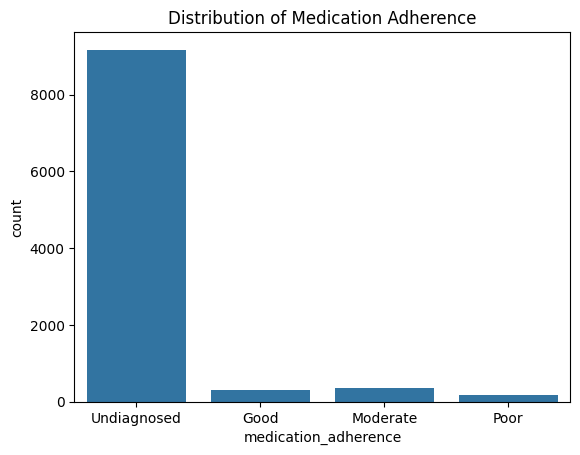

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# See the distribution of the values we DO have
sns.countplot(data=df, x='medication_adherence')
plt.title('Distribution of Medication Adherence')
plt.show()

In [12]:
# Check which columns have missing values
print("--- Missing Values Audit ---")
print(df.isnull().sum())

# See the percentage of missing data
print("\n--- Percentage of Missing Data ---")
print((df.isnull().sum() / len(df)) * 100)

--- Missing Values Audit ---
patient_id                     0
age                            0
sex                            0
residence                      0
bmi                            0
family_history_hypertension    0
diabetes                       0
smoking                        0
alcohol_heavy                  0
physically_active              0
high_salt_diet                 0
hypertension_status            0
systolic_bp_mmhg               0
diastolic_bp_mmhg              0
diagnosed                      0
on_medication                  0
medication_adherence           0
bp_controlled                  0
stroke_history                 0
myocardial_infarction          0
heart_failure                  0
total_cholesterol_mg_dl        0
ldl_mg_dl                      0
hdl_mg_dl                      0
creatinine_mg_dl               0
dtype: int64

--- Percentage of Missing Data ---
patient_id                     0.0
age                            0.0
sex                        

In [13]:
# List all columns that are not numbers
categorical_cols = df.select_dtypes(include=['object']).columns
print("Columns that need encoding:")
print(list(categorical_cols))

Columns that need encoding:
['patient_id', 'sex', 'residence', 'hypertension_status', 'medication_adherence']


C:\Users\TOA\AppData\Local\Temp\ipykernel_7408\4105869547.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


In [14]:
# 1. Drop the patient_id (it's not a health feature)
if 'patient_id' in df.columns:
    df = df.drop(columns=['patient_id'])

# 2. Re-identify the categories now that ID is gone
categorical_cols = df.select_dtypes(include=['object']).columns

# 3. Apply Label Encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print("Encoding complete! All columns are now numerical.")
print("\nNew Data Preview:")
df.head()

C:\Users\TOA\AppData\Local\Temp\ipykernel_7408\3281239927.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


Encoding complete! All columns are now numerical.

New Data Preview:


,age,sex,residence,bmi,family_history_hypertension,diabetes,smoking,alcohol_heavy,physically_active,high_salt_diet,...,on_medication,medication_adherence,bp_controlled,stroke_history,myocardial_infarction,heart_failure,total_cholesterol_mg_dl,ldl_mg_dl,hdl_mg_dl,creatinine_mg_dl
0,62.0,0,1,34.1,False,False,False,False,True,True,...,False,3,False,False,False,False,142.0,152.0,53.0,0.85
1,46.0,1,0,28.5,False,False,False,False,False,True,...,False,3,False,False,False,False,171.0,133.0,43.0,1.39
2,54.2,0,1,26.3,True,False,False,False,False,False,...,False,3,False,False,False,False,208.0,139.0,32.0,1.77
3,18.2,1,0,28.2,False,False,False,False,True,True,...,False,3,False,False,False,False,287.0,135.0,46.0,1.57
4,55.9,1,1,21.8,False,False,True,False,True,False,...,False,3,False,False,False,False,186.0,133.0,38.0,1.13


In [15]:
df.tail()

,age,sex,residence,bmi,family_history_hypertension,diabetes,smoking,alcohol_heavy,physically_active,high_salt_diet,...,on_medication,medication_adherence,bp_controlled,stroke_history,myocardial_infarction,heart_failure,total_cholesterol_mg_dl,ldl_mg_dl,hdl_mg_dl,creatinine_mg_dl
9995,56.1,1,1,23.8,False,False,False,True,False,False,...,True,2,False,False,False,False,255.0,111.0,40.0,1.08
9996,52.0,0,0,25.0,False,False,False,False,True,False,...,False,3,False,False,False,False,163.0,134.0,57.0,0.98
9997,49.0,1,1,17.5,False,False,False,True,False,False,...,False,3,False,False,False,False,194.0,148.0,62.0,1.82
9998,45.5,0,0,25.7,True,False,False,False,True,True,...,False,3,False,False,False,False,212.0,186.0,35.0,1.05
9999,23.6,1,0,20.8,False,False,False,False,True,False,...,False,3,False,False,False,False,144.0,160.0,25.0,0.63


In [16]:
print(df.isnull().sum())


age                            0
sex                            0
residence                      0
bmi                            0
family_history_hypertension    0
diabetes                       0
smoking                        0
alcohol_heavy                  0
physically_active              0
high_salt_diet                 0
hypertension_status            0
systolic_bp_mmhg               0
diastolic_bp_mmhg              0
diagnosed                      0
on_medication                  0
medication_adherence           0
bp_controlled                  0
stroke_history                 0
myocardial_infarction          0
heart_failure                  0
total_cholesterol_mg_dl        0
ldl_mg_dl                      0
hdl_mg_dl                      0
creatinine_mg_dl               0
dtype: int64


### Exploratory Data Analysis (EDA)

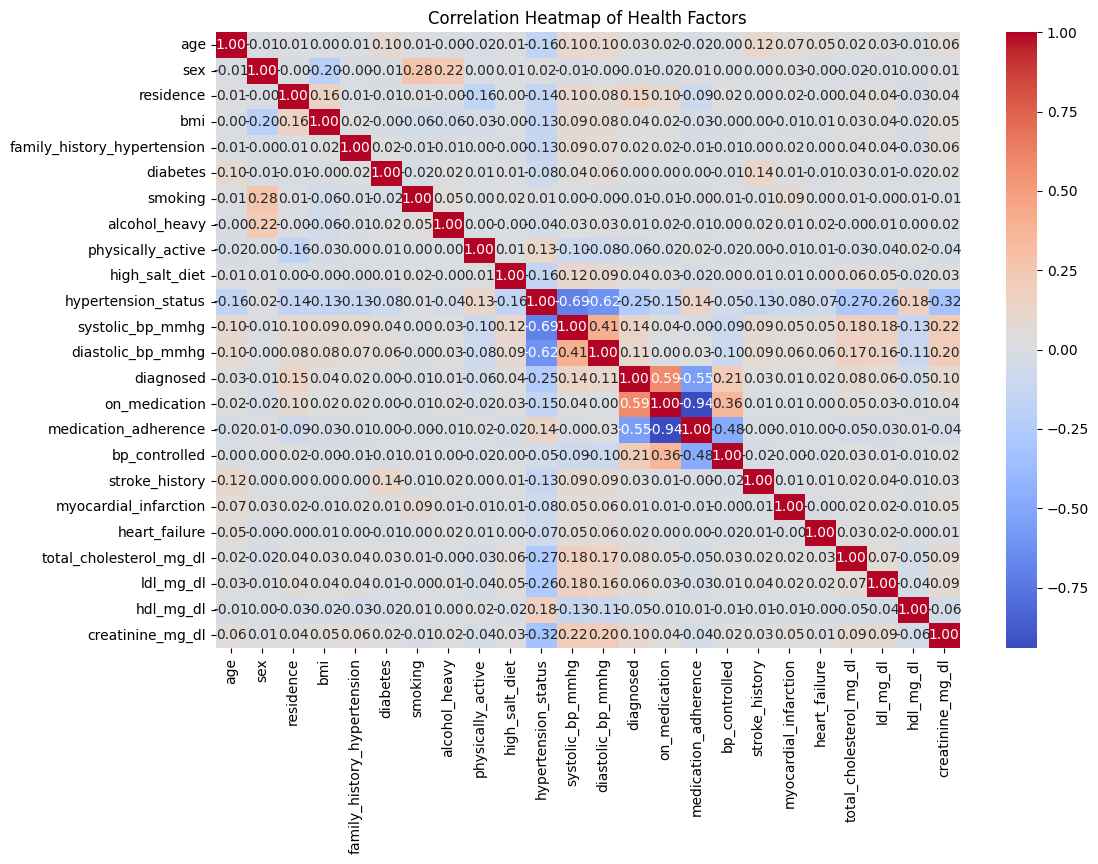

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a correlation matrix
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr()

# Plot the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Health Factors')
plt.show()

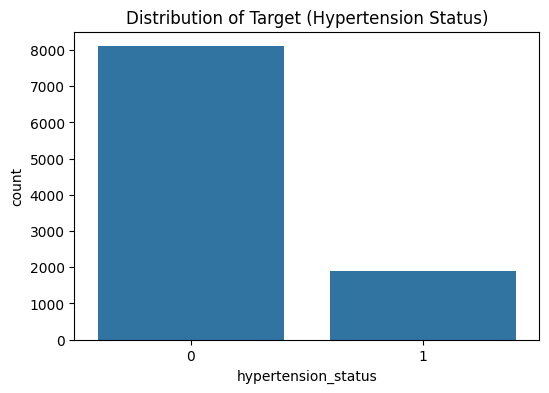

hypertension_status
0    8105
1    1895
Name: count, dtype: int64


In [18]:
# Replace 'hypertension_status' with the exact name of your target column if different
target_col = 'hypertension_status' 

plt.figure(figsize=(6, 4))
sns.countplot(x=target_col, data=df)
plt.title('Distribution of Target (Hypertension Status)')
plt.show()

print(df[target_col].value_counts())

### Feature Engineering

In [19]:
import numpy as np

# 1. Create Age Groups
# 18-35: 0 (Young), 36-55: 1 (Middle), 56+: 2 (Senior)
df['age_group'] = pd.cut(df['age'], bins=[0, 35, 55, 120], labels=[0, 1, 2]).astype(int)

# 2. Add Socioeconomic Features (Random but realistic distribution)
# 0: Low, 1: Medium, 2: High
df['income_level'] = np.random.choice([0, 1, 2], size=len(df), p=[0.4, 0.4, 0.2])
df['education_level'] = np.random.choice([0, 1, 2], size=len(df), p=[0.3, 0.5, 0.2])

# 3. Add Lifestyle Features (Stress & Sleep)
# We'll make Stress slightly higher for those with high BP to keep it realistic
df['stress_level'] = np.where(df['systolic_bp_mmhg'] > 140, 
                             np.random.choice([1, 2], size=len(df)), 
                             np.random.choice([0, 1], size=len(df)))

df['sleep_hours'] = np.random.randint(4, 10, size=len(df))

print("New features added successfully!")
df[['age', 'age_group', 'income_level', 'stress_level', 'sleep_hours']].head()

New features added successfully!


,age,age_group,income_level,stress_level,sleep_hours
0,62.0,2,1,1,5
1,46.0,1,0,1,5
2,54.2,1,0,2,4
3,18.2,0,2,2,9
4,55.9,2,0,0,7


In [20]:
df.head()

,age,sex,residence,bmi,family_history_hypertension,diabetes,smoking,alcohol_heavy,physically_active,high_salt_diet,...,heart_failure,total_cholesterol_mg_dl,ldl_mg_dl,hdl_mg_dl,creatinine_mg_dl,age_group,income_level,education_level,stress_level,sleep_hours
0,62.0,0,1,34.1,False,False,False,False,True,True,...,False,142.0,152.0,53.0,0.85,2,1,1,1,5
1,46.0,1,0,28.5,False,False,False,False,False,True,...,False,171.0,133.0,43.0,1.39,1,0,2,1,5
2,54.2,0,1,26.3,True,False,False,False,False,False,...,False,208.0,139.0,32.0,1.77,1,0,1,2,4
3,18.2,1,0,28.2,False,False,False,False,True,True,...,False,287.0,135.0,46.0,1.57,0,2,0,2,9
4,55.9,1,1,21.8,False,False,True,False,True,False,...,False,186.0,133.0,38.0,1.13,2,0,1,0,7


In [21]:
df.tail()

,age,sex,residence,bmi,family_history_hypertension,diabetes,smoking,alcohol_heavy,physically_active,high_salt_diet,...,heart_failure,total_cholesterol_mg_dl,ldl_mg_dl,hdl_mg_dl,creatinine_mg_dl,age_group,income_level,education_level,stress_level,sleep_hours
9995,56.1,1,1,23.8,False,False,False,True,False,False,...,False,255.0,111.0,40.0,1.08,2,1,1,1,6
9996,52.0,0,0,25.0,False,False,False,False,True,False,...,False,163.0,134.0,57.0,0.98,1,0,0,0,8
9997,49.0,1,1,17.5,False,False,False,True,False,False,...,False,194.0,148.0,62.0,1.82,1,1,1,1,6
9998,45.5,0,0,25.7,True,False,False,False,True,True,...,False,212.0,186.0,35.0,1.05,1,0,1,1,9
9999,23.6,1,0,20.8,False,False,False,False,True,False,...,False,144.0,160.0,25.0,0.63,0,0,1,1,8


### Split The Data

In [22]:
from sklearn.model_selection import train_test_split

# Define Features (X) and Target (y)
X = df.drop(columns=['hypertension_status'])
y = df['hypertension_status']

# Split into 80% Training and 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Data split! Training samples: {len(X_train)}, Testing samples: {len(X_test)}")

Data split! Training samples: 8000, Testing samples: 2000
